In [1]:
import importlib, sys

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from matplotlib.markers import MarkerStyle
from matplotlib.lines import Line2D

import superconductivity.api as sc

from superconductivity.api import G_0_muS
from superconductivity.api import NDArray64

from IPython import get_ipython

from tqdm import tqdm

Textwidth: float = 4.25279  # in
Textheight: float = 6.85173  # in

_ip = get_ipython()
if _ip is not None:
    _ip.run_line_magic("reload_ext", "autoreload")
    _ip.run_line_magic("autoreload", "2")

    _ip.run_line_magic(
        "config",
        "InlineBackend.print_figure_kwargs = {'bbox_inches': None, 'pad_inches': 0.0}",
    )
    _ip.run_line_magic("config", 'InlineBackend.figure_format = "retina"')  # or "png"
    _ip.run_line_magic("config", "InlineBackend.rc = {'figure.dpi': 300}")

In [2]:
# fit values

GN_G0: float = 0.18877592218372993
Delta_meV: float = 0.19345000789195935
gamma_meV: float = 0.005066874981090785
eta: float = 0.002173
nu_GHz: float = 13.6

eta = 0.002173  # (3)
Aoff_mV = -6.2e-3  # (13) mV
Tbase_K = 0.0806  # (46) K
Toff_K = -0.685  # (194) K
alphaT = 2.6811  # (458)

In [3]:
# import from pickle

HOME_DIR = "/Users/oliver/Documents/cryolab/p5control-bluefors-evaluation"
sys.path.append(HOME_DIR)

from utilities.ivplot import IVPlot

importlib.reload(sys.modules["utilities.ivplot"])

eva = IVPlot()
eva.title = f"amplitude at 13.6GHz"
eva.sub_folder = (
    "/Users/oliver/Documents/cryolab/superconductivity/evaluation/TB irradiation/data/"
)
eva.loadData()

Vbias_mV = eva.mapped["voltage_axis"] * 1e3
Ibias_nA = eva.mapped["current_axis"] * 1e9
Aout_mV = eva.mapped["y_axis"] * 1e3
dGexp_G0 = eva.up_sweep["differential_conductance"]
dRexp_R0 = eva.up_sweep["differential_resistance"]
Iexp_nA = eva.up_sweep["current"] * 1e9

(base) ... BaseClass initialized.
(base eva) ... BaseEvaluation initialized.
(iv eva) ... IVEvaluation initialized.
(base) ... BaseClass initialized.
(base plot) ... BasePlot initialized.
(iv plot) ... IVPlot initialized.
(base) amplitude at 13.6GHz
(base) loadData()


In [4]:
# Location
from superconductivity.evaluation.keys import list_measurement_keys

importlib.reload(sys.modules["superconductivity.evaluation.keys"])

location = "/Users/oliver/Documents/measurement data/25 04 OI-25c-09"
h5path = (
    f"{location}/OI-25c-09 2025-05-02 unbroken stripline irradiation studies 0.hdf5"
)
measurement = "vna_amplitudes_18.3000GHz"

mkeys = list_measurement_keys(h5path=h5path)

In [5]:
# handle keys
from superconductivity.evaluation import list_specific_keys_and_values

importlib.reload(sys.modules["superconductivity.evaluation"])

keys, Aout_V = list_specific_keys_and_values(
    h5path=h5path,
    measurement=measurement,
    strip0="GHz_",
    strip1="V",
    remove_key="no_irradiation",
    add_key=[
        ("no_irradiation", 0.0),
        ("no_irradiation", 0.005),
    ],
    limits=(None, 0.105),
)
Aout_mV = Aout_V * 1e3

In [6]:
# get traces

from superconductivity.evaluation import get_ivs

importlib.reload(sys.modules["superconductivity.evaluation"])

traces = get_ivs(
    h5path=h5path,
    measurement=measurement,
    keys=keys,
    yvalues=Aout_mV,
    amp_voltage=1000,
    amp_current=1000,
    trigger_values=1,
    skip=5,
)

In [7]:
# psd analysis

from superconductivity.evaluation import get_psds

importlib.reload(sys.modules["superconductivity.evaluation"])

psdtraces = get_psds(traces=traces, detrend=True)

In [8]:
# offset analysis

from superconductivity.evaluation import get_offsets, OffsetSpec

importlib.reload(sys.modules["superconductivity.evaluation"])

offsetspec = OffsetSpec(
    Vbins_mV=np.linspace(-0.5, 0.5, 51),
    Ibins_nA=np.linspace(-5, 5, 181),
    Voff_mV=np.linspace(-0.045, 0.045, 451),
    Ioff_nA=np.linspace(-0.35, 0.35, 701),
    nu_Hz=13.7,
    upsample=10,
)
offsets = get_offsets(
    traces=traces,
    spec=offsetspec,
    backend="jax",
)

get_offsets:   0%|          | 0/16 [00:00<?, ?trace/s]

In [9]:
# sampling

from superconductivity.evaluation import get_samplings, SamplingSpec

importlib.reload(sys.modules["superconductivity.evaluation"])

spec = SamplingSpec(
    nu_Hz=13.7,
    upsample=1000,
    Vbin_mV=np.linspace(-1.6, 1.6, 1601),
    Ibin_nA=np.linspace(-30.0, 30.0, 2001),
)

samples = get_samplings(
    traces=traces,
    offsets=offsets,
    spec=spec,
)

Vbias_mV = samples.Vbin_mV
Ibias_nA = samples.Ibin_nA
Iexp_nA = samples.I_nA
Vexp_mV = samples.V_mV
dGexp_G0 = samples.dG_G0
dRexp_R0 = samples.dR_R0

get_samplings:   0%|          | 0/16 [00:00<?, ?trace/s]

In [10]:
# smoothing

from superconductivity.evaluation import get_smoothed_samplings, SmoothingSpec

importlib.reload(sys.modules["superconductivity.evaluation"])

smoothspec = SmoothingSpec(
    median_bins=5,
    sigma_bins=2.0,
)

smooth = get_smoothed_samplings(
    samplings=samples,
    spec=smoothspec,
)

Vbias_mV = smooth.Vbin_mV
Ibias_nA = smooth.Ibin_nA
Iexp_nA = smooth.I_nA
Vexp_mV = smooth.V_mV
dGexp_G0 = smooth.dG_G0
dRexp_R0 = smooth.dR_R0

In [11]:
# from superconductivity.optimizers.old_pat.fit_pat import fit_I_nA

# importlib.reload(sys.modules["superconductivity.optimizers.old_pat.fit_pat"])

# solution = fit_I_nA(
#     V_mV=Vbias_mV,
#     I_nA=Iexp_nA[20, :],
#     G_N=(1.0, (0, 10.0), False),
#     T_K=(0.2, (0, 1.5), False),
#     Delta_meV=(0.195, (0.18, 0.21), False),
#     gamma_meV=(1e-3, (1e-3, 25e-3), False),
#     A_mV=(0.0, (0, 10.0), False),
#     nu_GHz=(7.8, (1.0, 20.0), False),
# )

In [12]:
# from superconductivity.optimizers.pat import fit_pat

# importlib.reload(sys.modules["superconductivity.optimizers.pat"])

# solution = fit_pat(V_mV=Vbias_mV, I_nA=Iexp_nA[10, :])

In [14]:
from superconductivity.optimizers.pat import fit_pat_gui

importlib.reload(sys.modules["superconductivity.optimizers.pat"])
solution = fit_pat_gui(V_mV=Vbias_mV, I_nA=Iexp_nA)

W0317 22:07:17.772869   67660 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


Panel server ready at http://127.0.0.1:49983 (Ctrl+C to stop and return the latest solution)
Final solution:
  GN_G0: 0.189162 ± 2.24588e-05
  T_K: 0.187017 ± 0.0589222
  Delta_mEV: 0.196005 ± 0.000145036
  gamma_meV: 0.00762177 ± 0.000109024
  A_mV: 0.0163543 ± 0.00136717
  nu_GHz: 1.07127 ± 6.19626


In [ ]:
from superconductivity.optimizers.pat import fit_pat_gui

handle = fit_pat_gui(V_mV=Vbias_mV, I_nA=Iexp_nA[10, :])
# Now go to the browser tab that opens and interact with the GUI.
# # When you're done, run:
# handle.stop()

In [32]:
import sys, socket

print("Python:", sys.executable)
try:
    s = socket.socket()
    s.bind(("localhost", 0))
    s.close()
    print("Socket bind succeeded")
except OSError as exc:
    print("Socket bind failed:", exc)

Python: /Users/oliver/Documents/cryolab/.venv/bin/python
Socket bind succeeded


In [2]:
# Test fit one curve
from superconductivity.optimizers.fit_pat import fit_I_nA
from superconductivity.optimizers.show_fitting import show_fitting, show_stats

importlib.reload(sys.modules["superconductivity.optimizers.fit_pat"])
importlib.reload(sys.modules["superconductivity.optimizers.show_fitting"])

solution0 = fit_I_nA(
    V_mV=Vbias_mV,
    I_nA=Iexp_nA[0, :],
    G_N=(0.18907387255862304, (0.1, 0.3), False),
    T_K=(0.23393265069546368, (0.0, 1.0), False),
    Delta_meV=(0.1955352791293755, (0.180, 0.2), False),
    gamma_meV=(0.004379851077615499, (1e-4, 30e-3), False),
    model="dynes",
)
show_fitting(solution0, num=0)
show_stats(solution0)

ModuleNotFoundError: No module named 'superconductivity.optimizers.fit_pat'

In [53]:
# fit the whole thing

I_fit_nA = np.full_like(Iexp_nA, np.nan, dtype="float64")
A_fit_mV = np.full_like(Aout_mV, np.nan, dtype="float64")
A_fit_err_mV = np.full_like(Aout_mV, np.nan, dtype="float64")
T_fit_K = np.full_like(Aout_mV, np.nan, dtype="float64")
T_fit_err_K = np.full_like(Aout_mV, np.nan, dtype="float64")

from superconductivity.optimizers.fit_pat import SolutionDict

solutions: list[SolutionDict] = []
for i, _ in enumerate(tqdm(Aout_mV)):
    if i > 1:
        a_mV = A_fit_mV[i - 1]
    else:
        a_mV = 0.0
    solution = fit_I_nA(
        V_mV=Vbias_mV,
        I_nA=Iexp_nA[i, :],
        G_N=(solution0["G_N"], (0.1, 0.3), True),
        T_K=(solution0["T_K"], (0.0, 1.2), False),
        Delta_meV=(solution0["Delta_mV"], (0.190, 0.2), True),
        gamma_meV=(solution0["gamma_mV"], (1e-4, 30e-3), True),
        A_mV=(a_mV, (0, 4), False),
        nu_GHz=(nu_GHz, (nu_GHz * 0.9, nu_GHz * 1.1), False),
        model="dynes+pat",
        optimizer="curve_fit",
    )
    I_fit_nA[i, :] = solution["I_fit_nA"]
    A_fit_mV[i] = solution["A_mV"]
    T_fit_K[i] = solution["T_K"]

    T_fit_err_K[i] = solution["perr"][1]
    A_fit_err_mV[i] = solution["perr"][4]
    solutions.append(solution)

100%|██████████| 101/101 [20:36<00:00, 12.24s/it]


In [63]:
from scipy.optimize import curve_fit


def calibration_A(x_data, eta: float, A_off: float):
    A_cal = A_off + eta * x_data
    return A_cal


A_popt, A_pcov = curve_fit(
    f=calibration_A,
    xdata=np.array(Aout_mV, dtype="float64"),
    ydata=np.array(A_fit_mV, dtype="float64"),
)
A_perr = np.sqrt(np.diag(A_pcov))
A_popt

array([ 0.00084489, -0.00794814])

In [ ]:
# data to plot
nu_GHz = 18.3
eta = A_popt[0]
Delta_meV = solution0["Delta_mV"]

Vbias = Vbias_mV / Delta_meV
Abias = Aout_mV * (eta) / (sc.h_e_pVs * nu_GHz)
Ibias = Ibias_nA / (Delta_meV * GN_G0 * sc.G_0_muS)
Iexp = Iexp_nA / (Delta_meV * GN_G0 * sc.G_0_muS)
dGexp = dGexp_G0 / GN_G0
dRexp = dRexp_R0 * GN_G0

Aintrest = [0, 0.96586225, 1.93172449, 3.09075919, 4.05662144]

Vbiaslim = (-0.5, 4.5)
Abiaslim = (0, 5)
Ibiaslim = (-0.5, 4.5)
Ilim = (-0.05, 4.5)
dRlim = (-0.05, 4.5)
dGlim = (-0.05, 4.5)

Iexp = np.clip(Iexp, Ilim[0], Ilim[1])
# dGexp = np.where(dGexp > dGlim[1], 5, dGexp)
# dRexp = np.where(dRexp > dRlim[1], 5, dRexp)
dGexp = np.clip(dGexp, dGlim[0], dGlim[1])
dRexp = np.clip(dRexp, dRlim[0], dRlim[1])

Vlabel = r"$eV\,/\,\Delta_0$"
Alabel = r"$eA\,/\,h\nu$"
Ilabel = r"$eI\,/\,\Delta_0 G_\mathrm{N}$"
dGlabel = r"$\mathrm{d}I/\mathrm{d}V\,/\,G_\mathrm{N}$"
dRlabel = r"$\mathrm{d}V/\mathrm{d}I\,/\,R_\mathrm{N}$"

Vbiasticks = [0, 2, 4]
Abiasticks = [0, 2, 4]
Ibiasticks = [0, 2, 4]
Iticks = [0, 2, 4]
dGticks = [0, 2, 4]
dRticks = [0, 2, 4]

Vbiasticklabels = None
Abiasticklabels = None
Ibiasticklabels = None
Iticklabels = None
dGticklabels = None
dRticklabels = None

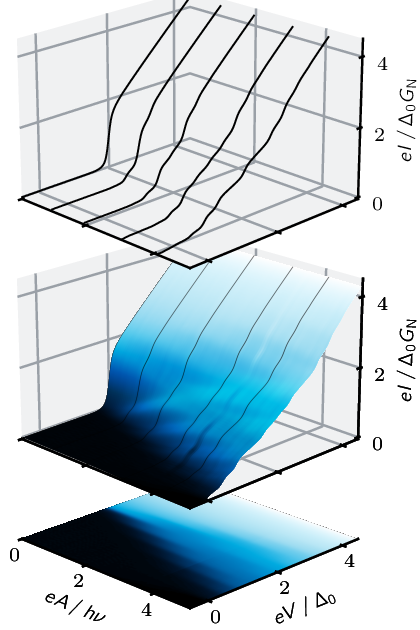

/Users/oliver/Documents/cryolab/superconductivity/thesis/results/tunnelbarrier/1_raw_iv/main.png

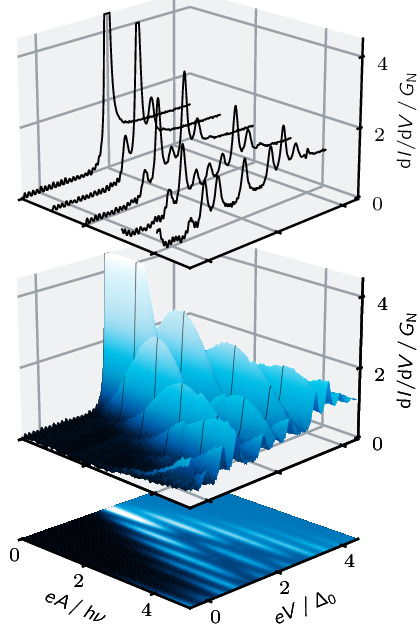

/Users/oliver/Documents/cryolab/superconductivity/thesis/results/tunnelbarrier/1_raw_didv/main.png

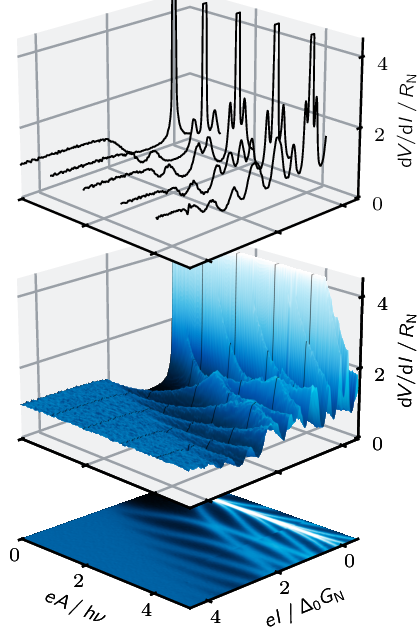

/Users/oliver/Documents/cryolab/superconductivity/thesis/results/tunnelbarrier/1_raw_dvdi/main.png

In [67]:
# plot the data

import superconductivity.visuals.thesis.latex as thesis_latex

importlib.reload(thesis_latex)
export_stacked_waterfall_thesis = thesis_latex.export_stacked_waterfall_thesis

to_plot = (True, True, True)
# to_plot = (False, True, False)
sub_dir = "results/tunnelbarrier/"
name = "1_raw"

# region setting
figsize = (2.1, 3.15)
subfigsize = (2.1, 2.1)
posx = (0, 0, 0)
posy = (1.6, 0.4, -0.1)
waterfall_traces = Aintrest
box_aspect = (1, 1, np.sqrt(2) / 2)
azim = 315 - 90
axes_rect = (0.0, 0.0, 1.85, 1.85)
x_axis = (False, False, True)
y_axis = (False, False, True)
labelspacing = (0.5, 0.5, 0.45)
ticklabelspacing = (0.35, 0.35, 0.5)
heatmap_cell_overlap = 0.7
z_axis_side = "right"
surface_x_oversample = 10
# endregion


# region plotting
if to_plot[0]:
    export = export_stacked_waterfall_thesis(
        x=Vbias,
        y=Abias,
        z=Iexp,
        name=f"{name}_iv",
        sub_dir=sub_dir,
        xlabel=Vlabel,
        ylabel=Alabel,
        zlabel=Ilabel,
        figsize=figsize,
        subfigsize=subfigsize,
        waterfall_traces=waterfall_traces,
        box_aspect=box_aspect,
        azim=azim,
        xlim=Vbiaslim,
        ylim=Abiaslim,
        zlim=Ilim,
        z_axis_side=z_axis_side,
        axes_rect=axes_rect,
        x_axis=x_axis,
        y_axis=y_axis,
        posx=posx,
        posy=posy,
        ticks=(Vbiasticks, Abiasticks, Iticks),
        ticklabels=(Vbiasticklabels, Abiasticklabels, Iticklabels),
        labelspacing=labelspacing,
        ticklabelspacing=ticklabelspacing,
        surface_x_oversample=surface_x_oversample,
    )

if to_plot[1]:
    export = export_stacked_waterfall_thesis(
        x=Vbias,
        y=Abias,
        z=dGexp,
        name=f"{name}_didv",
        sub_dir=sub_dir,
        xlabel=Vlabel,
        ylabel=Alabel,
        zlabel=dGlabel,
        figsize=figsize,
        subfigsize=subfigsize,
        waterfall_traces=waterfall_traces,
        box_aspect=box_aspect,
        azim=azim,
        xlim=Vbiaslim,
        ylim=Abiaslim,
        zlim=dGlim,
        z_axis_side=z_axis_side,
        axes_rect=axes_rect,
        x_axis=x_axis,
        y_axis=y_axis,
        posx=posx,
        posy=posy,
        ticks=(Vbiasticks, Abiasticks, dGticks),
        ticklabels=(Vbiasticklabels, Abiasticklabels, dGticklabels),
        labelspacing=labelspacing,
        ticklabelspacing=ticklabelspacing,
        surface_x_oversample=surface_x_oversample,
    )

if to_plot[2]:
    export = export_stacked_waterfall_thesis(
        x=Ibias,
        y=Abias,
        z=dRexp,
        name=f"{name}_dvdi",
        invert_xaxis=True,
        sub_dir=sub_dir,
        xlabel=Ilabel,
        ylabel=Alabel,
        zlabel=dRlabel,
        figsize=figsize,
        subfigsize=subfigsize,
        waterfall_traces=waterfall_traces,
        box_aspect=box_aspect,
        azim=azim,
        xlim=Ibiaslim,
        ylim=Abiaslim,
        zlim=dRlim,
        z_axis_side=z_axis_side,
        axes_rect=axes_rect,
        x_axis=x_axis,
        y_axis=y_axis,
        posx=posx,
        posy=posy,
        ticks=(Ibiasticks, Abiasticks, dRticks),
        ticklabels=(Ibiasticklabels, Abiasticklabels, dRticklabels),
        labelspacing=labelspacing,
        ticklabelspacing=ticklabelspacing,
        surface_x_oversample=surface_x_oversample,
    )
# endregion